<a href="https://colab.research.google.com/github/guhmtzz/CIAO_GUSTAVO_2026/blob/main/Aula_4_Desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


RELATORIO TECNICO — MOTOR DE DECISIONING SD-WAN ZERO-TRUST
Grau de conexao de cada no (num. de tuneis): [4 3 4 6 4 3 3 4 6 5 3 5]
Reputacao de seguranca por no: [100.   32.   21.8  83.   57.2  37.   80.4  59.4  28.6  44.4  84.1 100. ]
Nos classificados como NAO CONFIAVEIS (reputacao < 50): [1, 2, 5, 8, 9]
----------------------------------------------------------------------
Rota selecionada:        [np.int64(0), np.int64(3), np.int64(4), np.int64(11)]
Numero de saltos:        3
Latencia total:          52.96 ms
Perda de pacotes total:  12.70 %
Penalidade de seguranca: 0.00
Fitness final:           306.89
Tempo de execucao do AG: 4563.79 ms
----------------------------------------------------------------------
JUSTIFICATIVA DO DESVIO: os nos [1, 2, 5, 8, 9] tem reputacao de seguranca abaixo do limite Zero-Trust e foram DELIBERADAMENTE excluidos da rota pelo algoritmo genetico, mesmo existindo tunel fisico disponivel para eles. Qualquer rota que os incluisse sofreria a penalidade fixa 

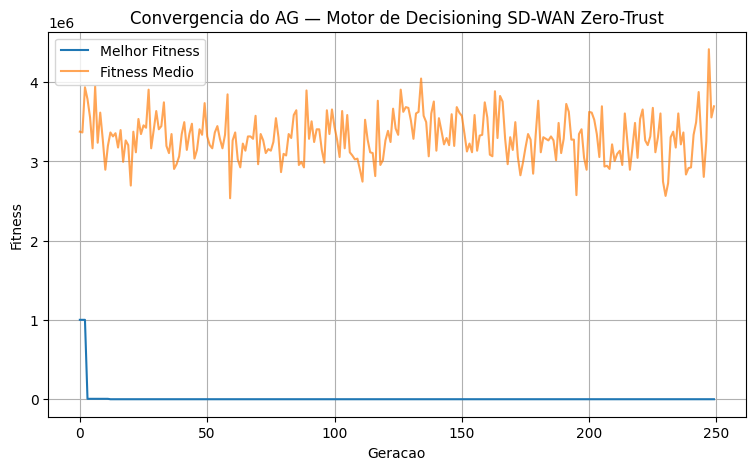

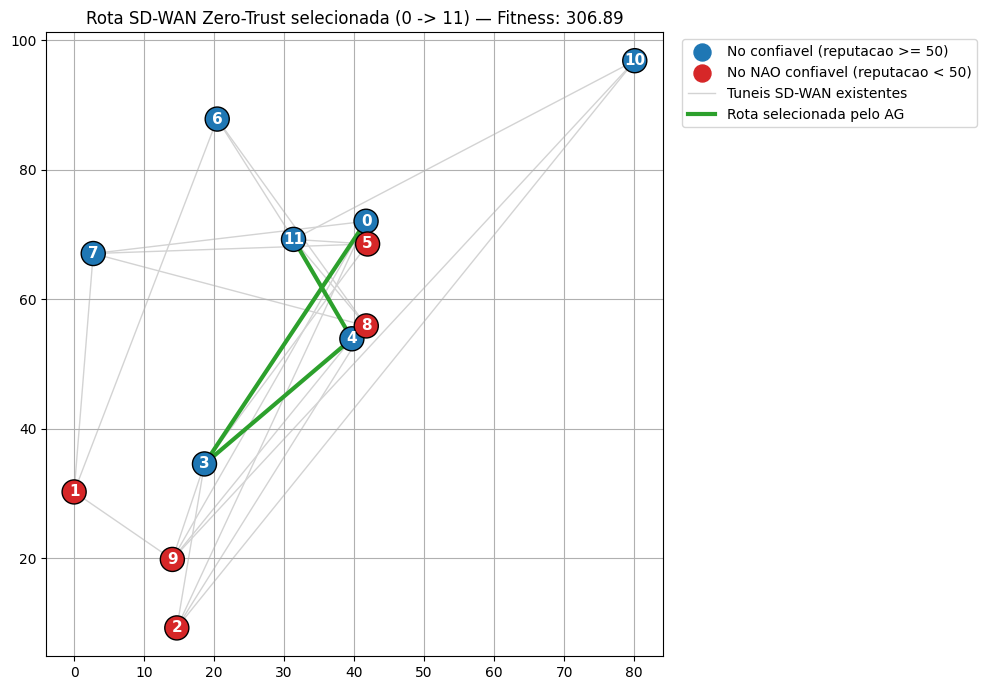

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(2026)


# ============================================================
# 1. CONFIGURACOES DO PROBLEMA
# ============================================================

NUM_NOS = 12
ORIGEM = 0
DESTINO = 11

TAMANHO_POPULACAO = 100
NUM_GERACOES = 250
TAXA_MUTACAO = 0.25

# Pesos da funcao de fitness
W1_LATENCIA = 1.0      # peso da latencia total (ms)
W2_PERDA = 20.0        # peso da perda de pacotes total (%) - maior peso pois
                       # perda de pacotes tende a ser mais critica que alguns ms extras
PENALIDADE_SEGURANCA = 5000.0
REPUTACAO_MINIMA = 50.0

# Custo aplicado a pares de nos SEM tunel logico estabelecido entre eles.
# Precisa ser grande o suficiente para que o AG NUNCA prefira um enlace
# inexistente a um enlace real, mesmo que este cruze um no nao confiavel.
LATENCIA_ENLACE_INEXISTENTE = 1_000_000.0
PERDA_ENLACE_INEXISTENTE = 100.0


# ============================================================
# 2. GERACAO DA TOPOLOGIA SD-WAN (ESPARSA E CONECTADA)
# ============================================================

# --- 2.1 Backbone aleatorio: garante que todos os 12 nos estao conectados ---
adjacencia = np.zeros((NUM_NOS, NUM_NOS), dtype=bool)

ordem_backbone = np.random.permutation(NUM_NOS)
for i in range(NUM_NOS - 1):
    a, b = ordem_backbone[i], ordem_backbone[i + 1]
    adjacencia[a, b] = True
    adjacencia[b, a] = True

# --- 2.2 Enlaces extras aleatorios (oferecem rotas alternativas) ---
pares_possiveis = [(i, j) for i in range(NUM_NOS) for j in range(i + 1, NUM_NOS)]
np.random.shuffle(pares_possiveis)

NUM_ENLACES_EXTRAS = 14
extras_adicionadas = 0
for (i, j) in pares_possiveis:
    if extras_adicionadas >= NUM_ENLACES_EXTRAS:
        break
    if not adjacencia[i, j] and not (i == ORIGEM and j == DESTINO):
        adjacencia[i, j] = True
        adjacencia[j, i] = True
        extras_adicionadas += 1

# --- 2.3 Remove explicitamente qualquer enlace direto Origem-Destino ---
# (cenario realista: sites distantes raramente tem tunel direto contratado)
adjacencia[ORIGEM, DESTINO] = False
adjacencia[DESTINO, ORIGEM] = False

# --- 2.4 Atributos dos enlaces existentes ---
matriz_latencia_real = np.random.uniform(2, 40, (NUM_NOS, NUM_NOS))
matriz_latencia_real = (matriz_latencia_real + matriz_latencia_real.T) / 2

matriz_perda_real = np.random.uniform(0, 8, (NUM_NOS, NUM_NOS))
matriz_perda_real = (matriz_perda_real + matriz_perda_real.T) / 2

# Matrizes finais: enlace existente -> valor real; enlace inexistente -> penalizacao
matriz_latencia = np.where(adjacencia, matriz_latencia_real, LATENCIA_ENLACE_INEXISTENTE)
matriz_perda = np.where(adjacencia, matriz_perda_real, PERDA_ENLACE_INEXISTENTE)
np.fill_diagonal(matriz_latencia, 0)
np.fill_diagonal(matriz_perda, 0)

# --- 2.5 Indice de reputacao de seguranca por NO [0,100] ---
reputacao_nos = np.random.uniform(20, 100, NUM_NOS)
# Origem e destino sao os proprios data centers corporativos: confiaveis por definicao
reputacao_nos[ORIGEM] = 100.0
reputacao_nos[DESTINO] = 100.0

nos_nao_confiaveis = [i for i in range(NUM_NOS) if reputacao_nos[i] < REPUTACAO_MINIMA]


# ============================================================
# 3. EXTRACAO DA ROTA A PARTIR DO CROMOSSOMO
# ============================================================

def extrair_rota(cromossomo, destino):
    """
    A rota efetivamente usada e o prefixo do cromossomo ate a primeira
    ocorrencia do no destino (inclusive). O restante do cromossomo (apos o
    destino) e material nao codificante.
    """
    idx_destino = np.where(cromossomo == destino)[0][0]
    return cromossomo[:idx_destino + 1]


# ============================================================
# 4. FUNCAO DE FITNESS
# ============================================================

def calcular_latencia_total(rota, matriz_latencia):
    return sum(
        matriz_latencia[rota[i], rota[i + 1]]
        for i in range(len(rota) - 1)
    )


def calcular_perda_total(rota, matriz_perda):
    """Combinacao probabilistica da perda de pacotes ao longo dos saltos."""
    prob_sucesso = 1.0
    for i in range(len(rota) - 1):
        p = min(matriz_perda[rota[i], rota[i + 1]], 100.0) / 100.0
        prob_sucesso *= (1.0 - p)
    return (1.0 - prob_sucesso) * 100.0


def calcular_penalidade_seguranca(rota, reputacao_nos, reputacao_minima, penalidade):
    if np.any(reputacao_nos[rota] < reputacao_minima):
        return penalidade
    return 0.0


def calcular_fitness(cromossomo, destino, matriz_latencia, matriz_perda,
                      reputacao_nos, reputacao_minima, penalidade,
                      w1, w2):
    rota = extrair_rota(cromossomo, destino)

    latencia_total = calcular_latencia_total(rota, matriz_latencia)
    perda_total = calcular_perda_total(rota, matriz_perda)
    p_seguranca = calcular_penalidade_seguranca(rota, reputacao_nos, reputacao_minima, penalidade)

    fitness = w1 * latencia_total + w2 * perda_total + p_seguranca
    return fitness, latencia_total, perda_total, p_seguranca, rota


# ============================================================
# 5. OPERADORES GENETICOS (mesma base: OX + Swap)
# A origem (posicao 0) e sempre fixa; OX e Swap atuam apenas nas posicoes 1..11
# ============================================================

def criar_individuo():
    """Origem fixa na posicao 0; permutacao aleatoria dos demais 11 nos."""
    genes_restantes = np.random.permutation(
        [n for n in range(NUM_NOS) if n != ORIGEM]
    )
    return np.concatenate(([ORIGEM], genes_restantes))


def criar_populacao(tamanho_populacao):
    return [criar_individuo() for _ in range(tamanho_populacao)]


def crossover_ox(pai1, pai2):
    """
    Ordered Crossover (OX), aplicado apenas no segmento movel (posicoes 1..11).
    A posicao 0 (origem) permanece fixa em ambos os pais e no filho.
    """
    segmento_pai1 = pai1[1:]
    segmento_pai2 = pai2[1:]
    tamanho = len(segmento_pai1)

    filho_segmento = np.full(tamanho, -1, dtype=int)

    ponto1, ponto2 = sorted(np.random.choice(tamanho, 2, replace=False))
    filho_segmento[ponto1:ponto2] = segmento_pai1[ponto1:ponto2]

    posicao = ponto2
    for elemento in segmento_pai2:
        if elemento not in filho_segmento:
            if posicao >= tamanho:
                posicao = 0
            filho_segmento[posicao] = elemento
            posicao += 1

    return np.concatenate(([ORIGEM], filho_segmento))


def mutacao_swap(cromossomo, taxa_mutacao):
    """Troca duas posicoes do segmento movel (nunca a posicao 0 - origem)."""
    cromossomo = cromossomo.copy()
    if np.random.rand() < taxa_mutacao:
        idx1, idx2 = np.random.choice(range(1, NUM_NOS), 2, replace=False)
        cromossomo[idx1], cromossomo[idx2] = cromossomo[idx2], cromossomo[idx1]
    return cromossomo


def selecao_torneio(populacao, fitness_populacao, tamanho_torneio=3):
    participantes = np.random.choice(len(populacao), tamanho_torneio, replace=False)
    melhor = participantes[np.argmin([fitness_populacao[i] for i in participantes])]
    return populacao[melhor]


# ============================================================
# 6. EXECUCAO DO ALGORITMO GENETICO
# ============================================================

populacao = criar_populacao(TAMANHO_POPULACAO)

historico_melhor = []
historico_medio = []

melhor_cromossomo_global = None
melhor_fitness_global = np.inf

tempo_inicio = time.time()

for geracao in range(NUM_GERACOES):

    resultados = [
        calcular_fitness(
            ind, DESTINO, matriz_latencia, matriz_perda,
            reputacao_nos, REPUTACAO_MINIMA, PENALIDADE_SEGURANCA,
            W1_LATENCIA, W2_PERDA
        )
        for ind in populacao
    ]
    fitness_populacao = [r[0] for r in resultados]

    indice_melhor = np.argmin(fitness_populacao)
    melhor_fit_geracao = fitness_populacao[indice_melhor]

    if melhor_fit_geracao < melhor_fitness_global:
        melhor_fitness_global = melhor_fit_geracao
        melhor_cromossomo_global = populacao[indice_melhor].copy()

    historico_melhor.append(melhor_fitness_global)
    historico_medio.append(np.mean(fitness_populacao))

    # Elitismo
    nova_populacao = [melhor_cromossomo_global.copy()]

    # Reproducao
    while len(nova_populacao) < TAMANHO_POPULACAO:
        pai1 = selecao_torneio(populacao, fitness_populacao)
        pai2 = selecao_torneio(populacao, fitness_populacao)
        filho = crossover_ox(pai1, pai2)
        filho = mutacao_swap(filho, TAXA_MUTACAO)
        nova_populacao.append(filho)

    populacao = nova_populacao

tempo_fim = time.time()


# ============================================================
# 7. RELATORIO — SOBRE O DESAFIO E A SOLUCAO
# ============================================================

fitness_final, latencia_final, perda_final, penalidade_final, rota_final = calcular_fitness(
    melhor_cromossomo_global, DESTINO, matriz_latencia, matriz_perda,
    reputacao_nos, REPUTACAO_MINIMA, PENALIDADE_SEGURANCA,
    W1_LATENCIA, W2_PERDA
)

tempo_execucao = (tempo_fim - tempo_inicio) * 1000

nos_evitados_na_rota = [n for n in nos_nao_confiaveis if n not in rota_final]

relatorio = """
Sobre o desafio da SD-WAN

A ideia aqui foi simular uma rede com 12 "sites" (numerados de 0 a 11),
representando uma SD-WAN — tipo uma rede corporativa onde cada unidade se
conecta a outras através de túneis de internet. Só que não fiz todo mundo
conectado com todo mundo, porque isso não seria realista: na vida real, manter
um túnel direto entre dois sites custa dinheiro (contrato com operadora),
então cada site só tem link direto com alguns vizinhos. Eu garanti que a rede
inteira continuava conectada (ninguém fica isolado), mas removi de propósito
o link direto entre o ponto de partida (nó 0) e o destino (nó 11), pra
obrigar o algoritmo a decidir entre vários caminhos possíveis com múltiplos
saltos — o que é bem mais parecido com a realidade, já que datacenters em
lugares diferentes raramente têm conexão direta.

Cada link entre dois sites tem uma latência (em ms) e uma taxa de perda de
pacotes (%). Além disso, cada site individualmente tem uma "nota de
reputação de segurança" de 0 a 100 — se a nota for menor que 50, considero
aquele site não confiável (peguei emprestado o conceito de Zero-Trust, onde
você não confia em nada da rede por padrão).

Como representei a solução

Usei a mesma ideia de permutação que já vinha usando nos exercícios
anteriores (com Crossover OX e Mutação Swap), só que precisei adaptar
porque aqui a rota pode ter tamanho diferente a cada tentativa (às vezes
2 saltos, às vezes 5). A saída que encontrei foi: o cromossomo continua
sendo uma permutação de todos os 12 nós (com a origem sempre fixa na
primeira posição), mas a rota que realmente conta é só o pedaço do
cromossomo até o momento em que o destino aparece pela primeira vez. Tudo
que vem depois do destino no cromossomo eu simplesmente ignoro — é só
"genética de sobra" que mantém a permutação válida, mas não representa nada
na prática. Isso foi bom porque não precisei reinventar o crossover e a
mutação, só reaproveitei os mesmos operadores de sempre.

Como nem todo par de nós tem link direto, também precisei garantir que o
algoritmo não tentasse "inventar" um caminho que não existe. Resolvi isso
colocando um custo altíssimo de latência/perda pra qualquer par de nós sem
túnel — assim o próprio algoritmo aprende sozinho a evitar esses caminhos
inexistentes, sem eu precisar criar uma regra manual de validação.

A fórmula de fitness

Fitness = w1 × Latência Total + w2 × Perda de Pacotes Total + Penalidade de
Segurança

A penalidade de segurança é fixa em 5000 se qualquer nó da rota (incluindo
origem e destino) tiver reputação abaixo de 50. Se nenhum nó suspeito
estiver na rota, essa penalidade é zero.

Um detalhe que achei importante: não dá pra simplesmente somar as
porcentagens de perda de pacotes de cada salto, porque isso poderia passar
de 100% (o que não faz sentido — não existe "120% de perda"). O jeito certo
de calcular é pensando em probabilidade: a chance de um pacote sobreviver à
rota inteira é o produto da chance de sobreviver a cada salto individual.
Então a perda total real é:

Perda Total (%) = [1 − produto de (1 − perda de cada salto/100)] × 100

Foi essa fórmula que usei no código, em vez de uma soma simples — mais
correta tecnicamente e evita resultados absurdos.
"""

print(relatorio)


# ============================================================
# 8. GRAFICO DE CONVERGENCIA
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(historico_melhor, label="Melhor Fitness")
plt.plot(historico_medio, label="Fitness Medio", alpha=0.7)
plt.title("Convergencia do AG — Motor de Decisioning SD-WAN Zero-Trust")
plt.xlabel("Geracao")
plt.ylabel("Fitness")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 9. VISUALIZACAO DA TOPOLOGIA E DA ROTA SELECIONADA
# ============================================================

np.random.seed(1)  # apenas para posicionamento visual dos nos no grafico
posicoes_plot = np.random.uniform(0, 100, size=(NUM_NOS, 2))

plt.figure(figsize=(10, 7))

# Desenha TODOS os enlaces existentes da topologia (cinza claro, fundo)
for i in range(NUM_NOS):
    for j in range(i + 1, NUM_NOS):
        if adjacencia[i, j]:
            plt.plot(
                [posicoes_plot[i, 0], posicoes_plot[j, 0]],
                [posicoes_plot[i, 1], posicoes_plot[j, 1]],
                color="lightgray", linewidth=1, zorder=1
            )

# Desenha a rota selecionada em destaque
for i in range(len(rota_final) - 1):
    o, d = rota_final[i], rota_final[i + 1]
    plt.plot(
        [posicoes_plot[o, 0], posicoes_plot[d, 0]],
        [posicoes_plot[o, 1], posicoes_plot[d, 1]],
        color="tab:green", linewidth=3, zorder=2
    )

cores_nos = ["tab:red" if reputacao_nos[i] < REPUTACAO_MINIMA else "tab:blue" for i in range(NUM_NOS)]
plt.scatter(posicoes_plot[:, 0], posicoes_plot[:, 1], s=300, c=cores_nos, zorder=3, edgecolors="black")

for i, (x, y) in enumerate(posicoes_plot):
    plt.text(x, y, str(i), fontsize=11, ha="center", va="center", color="white", zorder=4, fontweight="bold")

plt.scatter([], [], c="tab:blue", s=150, label="No confiavel (reputacao >= 50)")
plt.scatter([], [], c="tab:red", s=150, label="No NAO confiavel (reputacao < 50)")
plt.plot([], [], color="lightgray", linewidth=1, label="Tuneis SD-WAN existentes")
plt.plot([], [], color="tab:green", linewidth=3, label="Rota selecionada pelo AG")

plt.title(f"Rota SD-WAN Zero-Trust selecionada (0 -> 11) — Fitness: {fitness_final:.2f}")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.tight_layout()
plt.show()